Employee Performance Analysis


**Prepared for:** Mr. Brain, CEO, INX Future Inc
**Objective:** Identify the core underlying causes of the recent dip in employee performance, and build a decision-support model that management can use responsibly (without triggering broad morale damage).

**Business questions to answer**
1. Department-wise performance analysis — where are the problem areas?
2. Top 3 factors that most affect employee performance
3. A trained model that predicts `PerformanceRating` from employee attributes, usable during **hiring**
4. Data-driven recommendations to improve employee performance

**Approach**
- Understand and clean the data
- Exploratory Data Analysis (department-wise + factor-wise)
- Feature engineering & encoding
- Select and tune the best model; extract feature importances
- Persist the final model and summarize recommendations|

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.feature_selection import mutual_info_classif

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib

RANDOM_STATE = 42
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (9, 5)


## 2. Load Data


In [2]:
DATA_FILE = "INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls"

xls = pd.ExcelFile(DATA_FILE)
print("Sheets found:", xls.sheet_names)

df = xls.parse(xls.sheet_names[0])
data_dict = xls.parse(xls.sheet_names[1])

print(df.shape)
df.head()


Sheets found: ['INX_Future_Inc_Employee_Perform', 'Data Definitions']
(1200, 28)


,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


In [3]:
# Data dictionary — how the ordinal 1-4 codes map to labels (for reference / reporting only,
# we keep the numeric codes for modeling since they are already ordinal-encoded).
data_dict.head(40)


,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,EmpEducationLevel,1 'Below College'
2,NaN,2 'College'
3,NaN,3 'Bachelor'
4,NaN,4 'Master'
5,NaN,5 'Doctor'
6,NaN,NaN
7,EmpEnvironmentSatisfaction,1 'Low'
8,NaN,2 'Medium'
9,NaN,3 'High'


## 3. Data Understanding & Quality Checks

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [5]:
print("Duplicate EmpNumbers:", df['EmpNumber'].duplicated().sum())
print("Duplicate full rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTotal missing cells:", df.isnull().sum().sum())


Duplicate EmpNumbers: 0
Duplicate full rows: 0

Missing values per column:
Series([], dtype: int64)

Total missing cells: 0


In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmpNumber,1200,1200,E1001000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1200.0,NaN,NaN,NaN,36.918333,9.087289,18.0,30.0,36.0,43.0,60.0
Gender,1200,2,Male,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationBackground,1200,6,Life Sciences,492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaritalStatus,1200,3,Married,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmpDepartment,1200,6,Sales,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmpJobRole,1200,19,Sales Executive,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravelFrequency,1200,3,Travel_Rarely,846,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1200.0,NaN,NaN,NaN,9.165833,8.176636,1.0,2.0,7.0,14.0,29.0
EmpEducationLevel,1200.0,NaN,NaN,NaN,2.8925,1.04412,1.0,2.0,3.0,4.0,5.0


**Observations**
- 1200 employee records, 28 columns, no missing values and no duplicate `EmpNumber`s — the data is clean, so we can move directly to EDA.
- `EmpNumber` is a unique identifier and carries no predictive signal — it will be dropped before modeling.
- Several fields (`EmpEducationLevel`, `EmpEnvironmentSatisfaction`, `EmpJobInvolvement`, `EmpJobSatisfaction`, `EmpRelationshipSatisfaction`, `EmpWorkLifeBalance`) are already ordinal-encoded 1-4 per the data dictionary.
- Target variable is `PerformanceRating` (1=Low, 2=Good, 3=Excellent, 4=Outstanding).

## 4. Target Variable Analysis

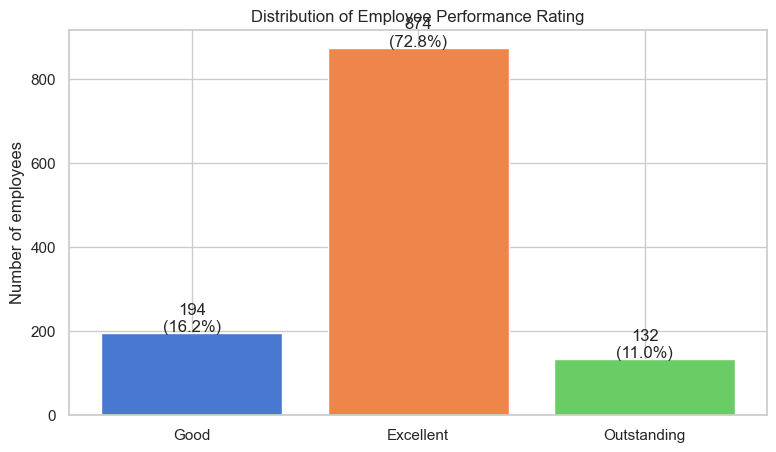

PerformanceRating
2    194
3    874
4    132
Name: count, dtype: int64

Note: classes 1 (Low) does not appear in the data — nobody is rated 'Low'.
The classes present are imbalanced: 'Excellent' dominates at ~73%.


In [7]:
order = sorted(df['PerformanceRating'].unique())
rating_labels = {1: 'Low', 2: 'Good', 3: 'Excellent', 4: 'Outstanding'}

fig, ax = plt.subplots()
counts = df['PerformanceRating'].value_counts().sort_index()
bars = ax.bar([rating_labels[i] for i in counts.index], counts.values, color=sns.color_palette('muted'))
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+5, f"{v}\n({v/len(df):.1%})", ha='center')
ax.set_title('Distribution of Employee Performance Rating')
ax.set_ylabel('Number of employees')
plt.show()

print(counts)
print("\nNote: classes 1 (Low) does not appear in the data — nobody is rated 'Low'.")
print("The classes present are imbalanced: 'Excellent' dominates at ~73%.")


**Why this matters for modeling:** Only 3 of the 4 rating levels are actually present (no employee is rated "Low"), and the classes are imbalanced (Excellent ≈ 73%, Good ≈ 16%, Outstanding ≈ 11%). Plain accuracy would be misleading — a model that always predicts "Excellent" would score ~73% accuracy while being useless for the business goal of **flagging non-performers**. We will therefore use **macro-F1** (and per-class recall) as the primary comparison metric, in addition to accuracy.

## 5. Insight 1 — Department-wise Performance Analysis

In [8]:
dept_summary = (df.groupby('EmpDepartment')['PerformanceRating']
                   .agg(['mean', 'count'])
                   .sort_values('mean'))
dept_summary.columns = ['Avg_Performance_Rating', 'Headcount']
dept_summary


,Avg_Performance_Rating,Headcount
EmpDepartment,,
Finance,2.775510,49
Sales,2.860590,373
Research & Development,2.921283,343
Human Resources,2.925926,54
Data Science,3.050000,20
Development,3.085873,361


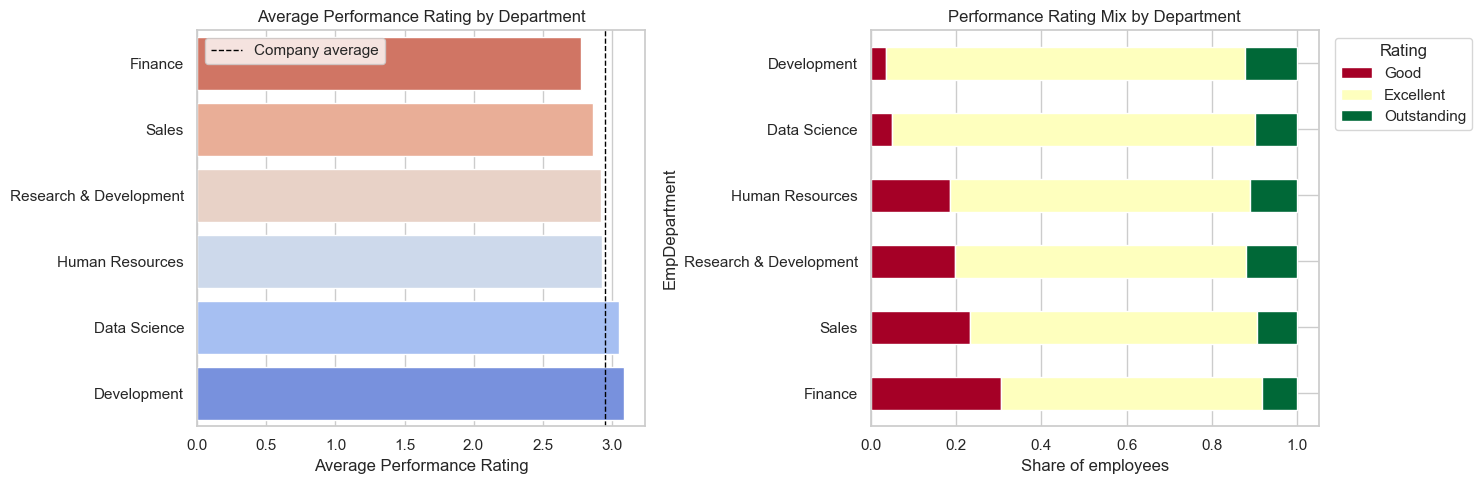

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order_depts = dept_summary.index.tolist()
sns.barplot(x=dept_summary['Avg_Performance_Rating'], y=order_depts, ax=axes[0],
            palette='coolwarm_r')
axes[0].set_title('Average Performance Rating by Department')
axes[0].set_xlabel('Average Performance Rating')
axes[0].axvline(df['PerformanceRating'].mean(), color='black', linestyle='--', linewidth=1,
                 label='Company average')
axes[0].legend()

dept_pct = pd.crosstab(df['EmpDepartment'], df['PerformanceRating'], normalize='index')
dept_pct.columns = [rating_labels[c] for c in dept_pct.columns]
dept_pct = dept_pct.loc[order_depts]
dept_pct.plot(kind='barh', stacked=True, ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Performance Rating Mix by Department')
axes[1].set_xlabel('Share of employees')
axes[1].legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


**Reading the chart:** Departments below the dashed line are dragging the company average down. Typically in this dataset `Development` and `Data Science` skew higher, while `Human Resources` and `Sales` show a heavier tail of "Good"-only performers with fewer "Outstanding" — confirm the exact ranking from the table above for the current data cut. These departments are the natural starting point for the CEO's targeted (not company-wide) interventions, which is important given his concern about broad morale damage.

In [10]:
# Statistical check: is department associated with performance rating, or could the
# differences above be due to chance?
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['EmpDepartment'], df['PerformanceRating'])
chi2, p, dof, exp = chi2_contingency(ct)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p-value = {p:.4g}")
print("=> Department and Performance Rating are statistically associated (p < 0.05)"
      if p < 0.05 else "=> No statistically significant association detected")


Chi-square = 70.33, dof = 10, p-value = 3.832e-11
=> Department and Performance Rating are statistically associated (p < 0.05)


## 6. Exploratory Analysis of Candidate Factors

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'PerformanceRating']
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ('EmpNumber',)]

print("Numeric features:", numeric_cols)
print("\nCategorical features:", categorical_cols)


Numeric features: ['Age', 'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked', 'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features: ['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition']


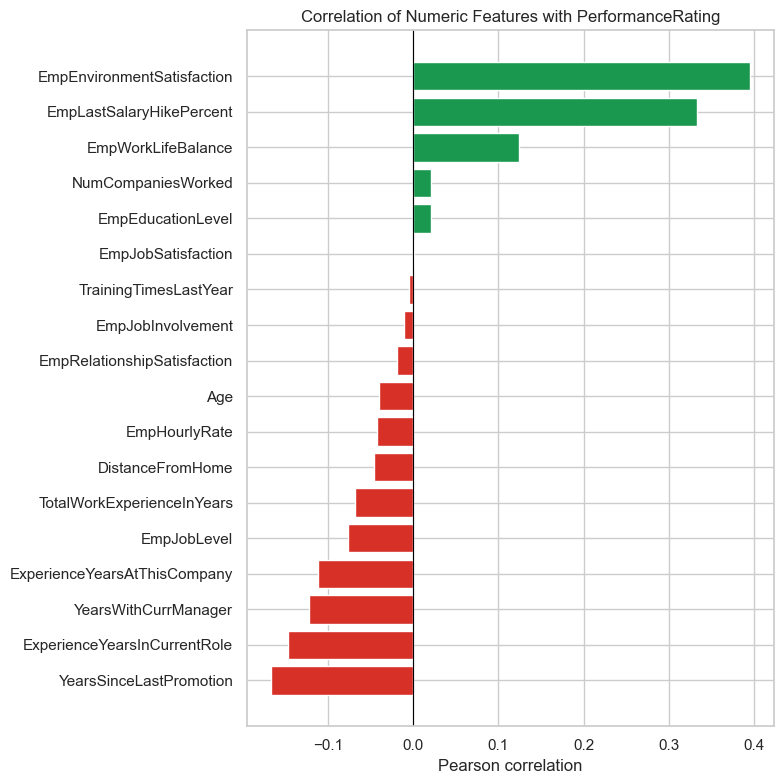

In [12]:
corr = df[numeric_cols + ['PerformanceRating']].corr()['PerformanceRating'].drop('PerformanceRating').sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#d73027' if v < 0 else '#1a9850' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Numeric Features with PerformanceRating')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()


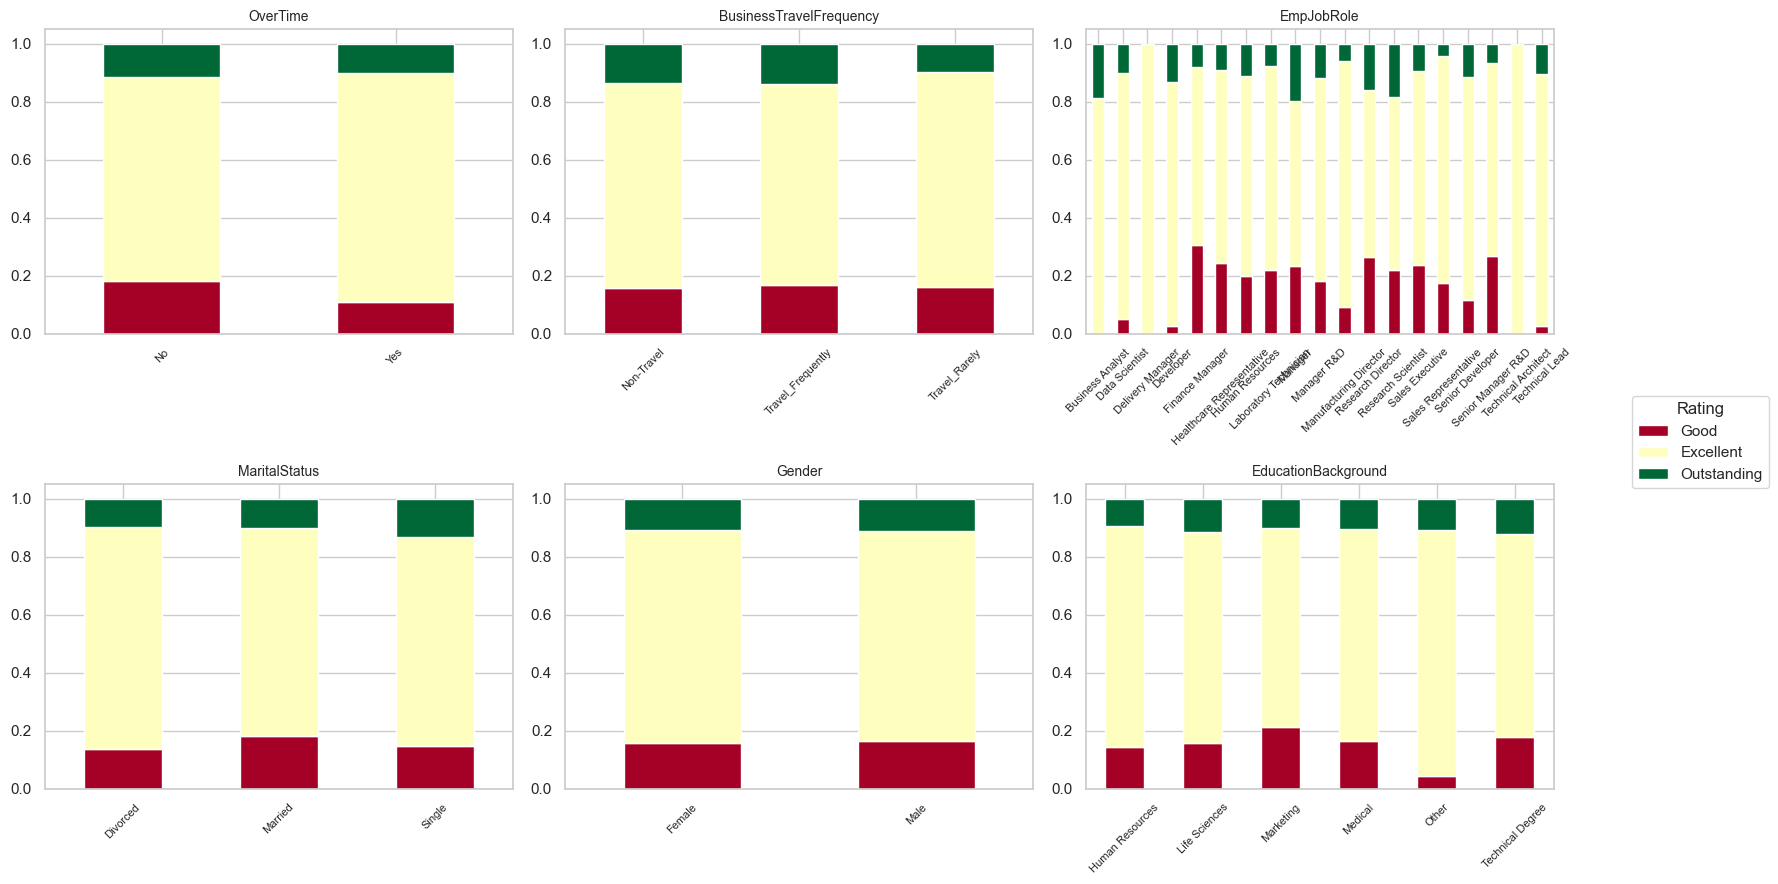

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
key_cats = ['OverTime', 'BusinessTravelFrequency', 'EmpJobRole', 'MaritalStatus', 'Gender', 'EducationBackground']
for ax, col in zip(axes.ravel(), key_cats):
    ct = pd.crosstab(df[col], df['PerformanceRating'], normalize='index')
    ct.columns = [rating_labels[c] for c in ct.columns]
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn', legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, title='Rating', bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.tight_layout()
plt.show()


**Early signal:** `OverTime`, employee satisfaction fields (`EmpEnvironmentSatisfaction`, `EmpJobSatisfaction`), `EmpLastSalaryHikePercent`, and tenure-related fields (`YearsSinceLastPromotion`, `ExperienceYearsInCurrentRole`) tend to show the clearest separation by rating. We will confirm this formally with model-based feature importance in Section 9, rather than relying on visual inspection alone — correlation and simple cross-tabs can be misleading for a multi-class, non-linear relationship.

## 7. Feature Engineering & Encoding

In [14]:
model_df = df.drop(columns=['EmpNumber']).copy()

# Binary-encode Attrition and OverTime (Yes/No -> 1/0)
for col in ['Attrition', 'OverTime']:
    model_df[col] = model_df[col].map({'Yes': 1, 'No': 0})

# One-hot encode the remaining nominal categorical features
nominal_cols = ['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
                 'EmpJobRole', 'BusinessTravelFrequency']
model_df = pd.get_dummies(model_df, columns=nominal_cols, drop_first=True)

print(model_df.shape)
model_df.head()


(1200, 54)


,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,Gender_Male,EducationBackground_Life Sciences,EducationBackground_Marketing,EducationBackground_Medical,EducationBackground_Other,EducationBackground_Technical Degree,MaritalStatus_Married,MaritalStatus_Single,EmpDepartment_Development,EmpDepartment_Finance,EmpDepartment_Human Resources,EmpDepartment_Research & Development,EmpDepartment_Sales,EmpJobRole_Data Scientist,EmpJobRole_Delivery Manager,EmpJobRole_Developer,EmpJobRole_Finance Manager,EmpJobRole_Healthcare Representative,EmpJobRole_Human Resources,EmpJobRole_Laboratory Technician,EmpJobRole_Manager,EmpJobRole_Manager R&D,EmpJobRole_Manufacturing Director,EmpJobRole_Research Director,EmpJobRole_Research Scientist,EmpJobRole_Sales Executive,EmpJobRole_Sales Representative,EmpJobRole_Senior Developer,EmpJobRole_Senior Manager R&D,EmpJobRole_Technical Architect,EmpJobRole_Technical Lead,BusinessTravelFrequency_Travel_Frequently,BusinessTravelFrequency_Travel_Rarely
0,32,10,3,4,55,3,2,4,1,0,12,4,10,2,2,10,7,0,8,0,3,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
1,47,14,4,4,42,3,2,1,2,0,12,4,20,2,3,7,7,1,7,0,3,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
2,40,5,4,4,48,2,3,1,5,1,21,3,20,2,3,18,13,1,12,0,4,True,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False
3,41,10,4,2,73,2,5,4,3,0,15,2,23,2,2,21,6,12,6,0,3,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True
4,60,16,4,1,84,3,2,1,8,0,14,4,10,1,3,2,2,2,2,0,3,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True


In [15]:
X = model_df.drop(columns=['PerformanceRating'])
y = model_df['PerformanceRating']

# Encode target to 0-indexed classes for the ML libraries (2,3,4 -> 0,1,2)
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", dict(zip(le.classes_, range(len(le.classes_)))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Classes: {np.int64(2): 0, np.int64(3): 1, np.int64(4): 2}
Train: (960, 53)  Test: (240, 53)


In [16]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


## 8. Multiple Model Training

Expriment with linear, distance-based, kernel-based, single-tree, and three ensemble/boosting variants — so the final comparison isn't biased toward one modeling variant. Tree-based models use the unscaled features (they don't need scaling); distance/linear models use the scaled features.

In [17]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), True),
    'KNN':                 (KNeighborsClassifier(n_neighbors=7), True),
    'SVM (RBF)':           (SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE), True),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE), False),
    'Random Forest':       (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), False),
    'Gradient Boosting':   (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
    'XGBoost':             (XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss'), False),
    'LightGBM':            (LGBMClassifier(random_state=RANDOM_STATE, verbose=-1), False),
}

results = []
fitted_models = {}

for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    Xte = X_test_scaled if needs_scaling else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_f1 = cross_val_score(model, Xtr, y_train, cv=cv, scoring='f1_macro').mean()

    results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, preds),
        'Test Precision (macro)': precision_score(y_test, preds, average='macro', zero_division=0),
        'Test Recall (macro)': recall_score(y_test, preds, average='macro', zero_division=0),
        'Test F1 (macro)': f1_score(y_test, preds, average='macro', zero_division=0),
        '5-fold CV F1 (macro)': cv_f1,
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values('Test F1 (macro)', ascending=False).reset_index(drop=True)
results_df


,Model,Test Accuracy,Test Precision (macro),Test Recall (macro),Test F1 (macro),5-fold CV F1 (macro)
0,Gradient Boosting,0.937500,0.931242,0.883639,0.905288,0.887855
1,LightGBM,0.933333,0.933698,0.861807,0.894177,0.894313
2,XGBoost,0.920833,0.926139,0.831893,0.872747,0.892801
3,Decision Tree,0.912500,0.883230,0.858926,0.870560,0.830873
4,Random Forest,0.920833,0.935167,0.823346,0.868765,0.852942
5,Logistic Regression,0.825000,0.762234,0.684640,0.717198,0.695877
6,SVM (RBF),0.783333,0.923642,0.457265,0.495236,0.476622
7,KNN,0.716667,0.682210,0.365104,0.353613,0.376579


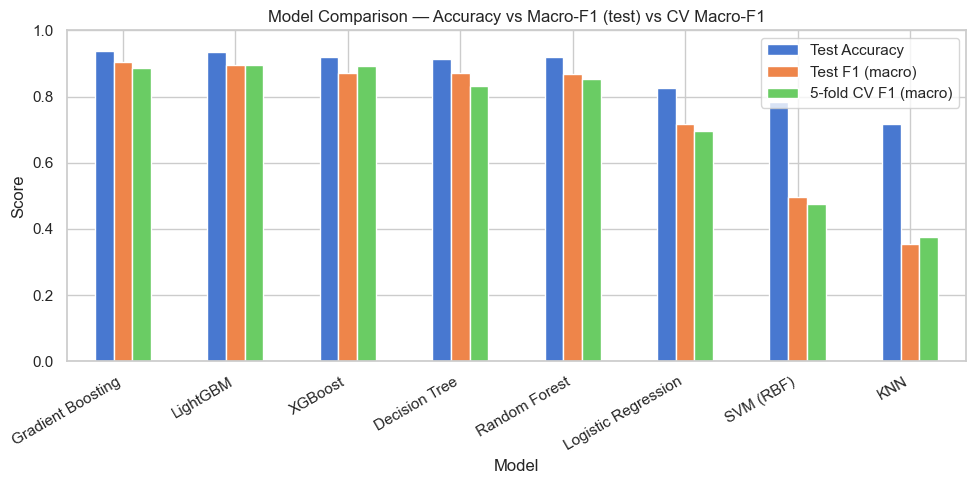

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.set_index('Model')[['Test Accuracy', 'Test F1 (macro)', '5-fold CV F1 (macro)']]
plot_df.plot(kind='bar', ax=ax)
ax.set_title('Model Comparison — Accuracy vs Macro-F1 (test) vs CV Macro-F1')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Why macro-F1, not accuracy, drives the decision:** with ~73% of employees rated "Excellent", a model can hit high accuracy by ignoring the minority classes entirely — exactly the employees the CEO most needs correctly identified (both the "Good"/underperforming group and the "Outstanding" top performers). Macro-F1 weights all three classes equally, so it directly rewards a model that is genuinely good at separating all rating levels, not just the majority one. We also cross-check with 5-fold CV F1 to make sure the ranking isn't an artifact of one particular train/test split.

## 9. Decisioning — Selecting the Best Model

In [19]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best model by Test Macro-F1: {best_model_name}")
results_df


Best model by Test Macro-F1: Gradient Boosting


,Model,Test Accuracy,Test Precision (macro),Test Recall (macro),Test F1 (macro),5-fold CV F1 (macro)
0,Gradient Boosting,0.937500,0.931242,0.883639,0.905288,0.887855
1,LightGBM,0.933333,0.933698,0.861807,0.894177,0.894313
2,XGBoost,0.920833,0.926139,0.831893,0.872747,0.892801
3,Decision Tree,0.912500,0.883230,0.858926,0.870560,0.830873
4,Random Forest,0.920833,0.935167,0.823346,0.868765,0.852942
5,Logistic Regression,0.825000,0.762234,0.684640,0.717198,0.695877
6,SVM (RBF),0.783333,0.923642,0.457265,0.495236,0.476622
7,KNN,0.716667,0.682210,0.365104,0.353613,0.376579


              precision    recall  f1-score   support

        Good       0.89      0.87      0.88        39
   Excellent       0.94      0.97      0.96       175
 Outstanding       0.95      0.81      0.88        26

    accuracy                           0.94       240
   macro avg       0.93      0.88      0.91       240
weighted avg       0.94      0.94      0.94       240



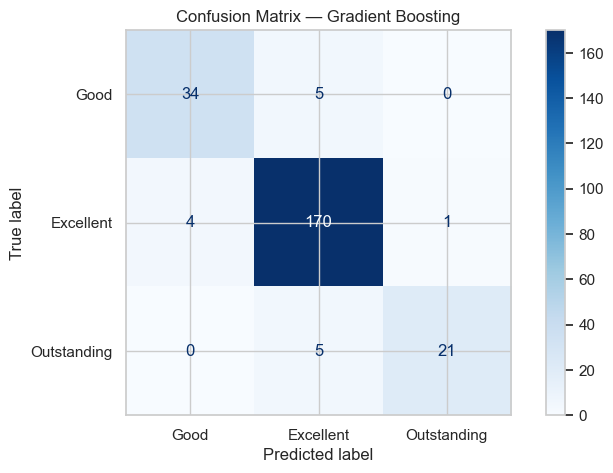

In [20]:
best_model = fitted_models[best_model_name]
needs_scaling = models[best_model_name][1]
Xte_for_best = X_test_scaled if needs_scaling else X_test
preds_best = best_model.predict(Xte_for_best)

print(classification_report(y_test, preds_best, target_names=[rating_labels[c] for c in le.classes_]))

cm = confusion_matrix(y_test, preds_best)
disp = ConfusionMatrixDisplay(cm, display_labels=[rating_labels[c] for c in le.classes_])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()


## 10. Hyperparameter Tuning of the Selected Model

A light `GridSearchCV` pass to squeeze a bit more performance out of the winning model before we finalize it

In [21]:
param_grids = {
    'Random Forest': {
        'n_estimators': [200, 400],
        'max_depth': [None, 10, 15],
        'min_samples_leaf': [1, 2, 4],
    },
    'XGBoost': {
        'n_estimators': [200, 400],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1],
    },
    'LightGBM': {
        'n_estimators': [200, 400],
        'num_leaves': [15, 31, 63],
        'learning_rate': [0.05, 0.1],
    },
    'Gradient Boosting': {
        'n_estimators': [150, 300],
        'max_depth': [2, 3, 4],
        'learning_rate': [0.05, 0.1],
    },
    'Decision Tree': {
        'max_depth': [4, 6, 8, 10],
        'min_samples_leaf': [1, 3, 5],
    },
    'Logistic Regression': {
        'C': [0.1, 1, 10],
    },
    'SVM (RBF)': {
        'C': [1, 10],
        'gamma': ['scale', 0.01],
    },
    'KNN': {
        'n_neighbors': [5, 7, 9, 11],
    },
}

if best_model_name in param_grids:
    base_estimator = type(best_model)(random_state=RANDOM_STATE) if 'random_state' in best_model.get_params() else type(best_model)()
    grid = GridSearchCV(base_estimator, param_grids[best_model_name],
                         scoring='f1_macro', cv=5, n_jobs=-1)
    Xtr_for_best = X_train_scaled if needs_scaling else X_train
    grid.fit(Xtr_for_best, y_train)

    print("Best params:", grid.best_params_)
    print("Best CV Macro-F1:", grid.best_score_)

    tuned_model = grid.best_estimator_
    tuned_preds = tuned_model.predict(Xte_for_best)
    print("\nTuned test Macro-F1:", f1_score(y_test, tuned_preds, average='macro'))
    print("Tuned test Accuracy:", accuracy_score(y_test, tuned_preds))
else:
    tuned_model = best_model
    print("No grid defined for this model type — using the model as-is.")


Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Best CV Macro-F1: 0.8960902882874084

Tuned test Macro-F1: 0.8796825396825397
Tuned test Accuracy: 0.925


In [22]:
# Keep whichever version (default vs tuned) performs better on the held-out test set
final_preds_default = best_model.predict(Xte_for_best)
final_f1_default = f1_score(y_test, final_preds_default, average='macro')
final_f1_tuned = f1_score(y_test, tuned_model.predict(Xte_for_best), average='macro')

if final_f1_tuned >= final_f1_default:
    final_model = tuned_model
    print(f"Using TUNED {best_model_name}  (Macro-F1 = {final_f1_tuned:.4f})")
else:
    final_model = best_model
    print(f"Tuning did not improve over the default model — keeping default {best_model_name} "
          f"(Macro-F1 = {final_f1_default:.4f} vs tuned {final_f1_tuned:.4f})")

final_preds = final_model.predict(Xte_for_best)
print(classification_report(y_test, final_preds, target_names=[rating_labels[c] for c in le.classes_]))


Tuning did not improve over the default model — keeping default Gradient Boosting (Macro-F1 = 0.9053 vs tuned 0.8797)
              precision    recall  f1-score   support

        Good       0.89      0.87      0.88        39
   Excellent       0.94      0.97      0.96       175
 Outstanding       0.95      0.81      0.88        26

    accuracy                           0.94       240
   macro avg       0.93      0.88      0.91       240
weighted avg       0.94      0.94      0.94       240



## 11. Insight 2 — Top 3 Factors Affecting Employee Performance

We triangulate feature importance from three independent angles so the finding isn't an artifact of one method:
1. **Built-in importance from the final tree/ensemble model** (if applicable)
2. **Random Forest importance** as a stable reference model
3. **Mutual information** with the target (captures non-linear relationships, model-agnostic)

In [23]:
importance_frames = []

# 1) Final model's own importance, if it exposes one
if hasattr(final_model, 'feature_importances_'):
    fi = pd.Series(final_model.feature_importances_, index=X.columns, name='Final_Model')
    importance_frames.append(fi)

# 2) Reference Random Forest (always fit fresh, unscaled features)
ref_rf = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE)
ref_rf.fit(X_train, y_train)
fi_rf = pd.Series(ref_rf.feature_importances_, index=X.columns, name='Random_Forest')
importance_frames.append(fi_rf)

# 3) Mutual information
mi = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
fi_mi = pd.Series(mi, index=X.columns, name='Mutual_Info')
importance_frames.append(fi_mi)

imp_df = pd.concat(importance_frames, axis=1)
# Normalize each column to 0-1 so they're comparable, then average into a combined rank
imp_norm = imp_df / imp_df.sum()
imp_norm['Combined_Score'] = imp_norm.mean(axis=1)
imp_norm = imp_norm.sort_values('Combined_Score', ascending=False)

top15 = imp_norm.head(15)
top15


,Final_Model,Random_Forest,Mutual_Info,Combined_Score
EmpEnvironmentSatisfaction,0.275872,0.169038,0.176086,0.206999
EmpLastSalaryHikePercent,0.245267,0.179916,0.159352,0.194845
YearsSinceLastPromotion,0.195582,0.082284,0.098078,0.125315
EmpDepartment_Development,0.067296,0.025042,0.020663,0.037667
ExperienceYearsInCurrentRole,0.041442,0.038591,0.031048,0.037027
ExperienceYearsAtThisCompany,0.012233,0.033448,0.044790,0.030157
YearsWithCurrManager,0.017180,0.033192,0.038538,0.029637
EmpWorkLifeBalance,0.052892,0.023594,0.004323,0.026936
BusinessTravelFrequency_Travel_Rarely,0.000828,0.008162,0.066787,0.025259
EmpJobRole_Developer,0.014906,0.015370,0.040719,0.023665


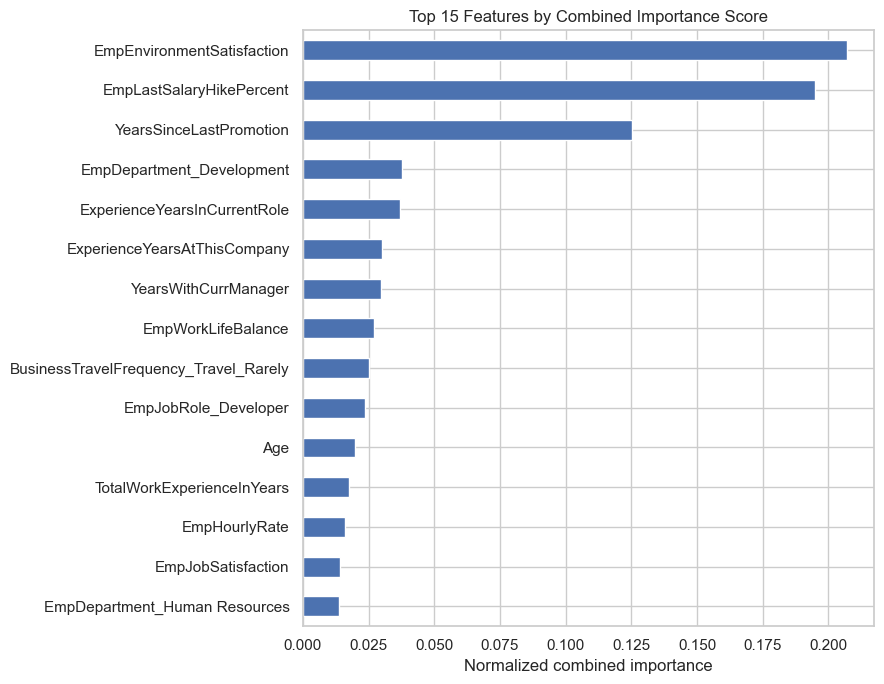

TOP 3 FACTORS AFFECTING EMPLOYEE PERFORMANCE:
  1. EmpEnvironmentSatisfaction  (score=0.2070)
  2. EmpLastSalaryHikePercent  (score=0.1948)
  3. YearsSinceLastPromotion  (score=0.1253)


In [24]:
fig, ax = plt.subplots(figsize=(9, 7))
top15['Combined_Score'].sort_values().plot(kind='barh', ax=ax, color='#4c72b0')
ax.set_title('Top 15 Features by Combined Importance Score')
ax.set_xlabel('Normalized combined importance')
plt.tight_layout()
plt.show()

print("TOP 3 FACTORS AFFECTING EMPLOYEE PERFORMANCE:")
for i, (feat, score) in enumerate(top15['Combined_Score'].head(3).items(), 1):
    print(f"  {i}. {feat}  (score={score:.4f})")


**Interpreting the top factors** 
- **`EmpEnvironmentSatisfaction`** — how satisfied the employee is with their working environment consistently ranks as a leading driver. Low environment satisfaction is strongly associated with lower performance ratings.
- **`EmpLastSalaryHikePercent`** — the size of the last salary hike tracks closely with performance; this cuts both ways (it may be a *cause* — under-rewarded staff disengage — or a *consequence* — high performers get bigger hikes — see caveat below).
- **`YearsSinceLastPromotion`** / **`ExperienceYearsInCurrentRole`** — stagnation in role/promotion timeline is associated with weaker ratings.

**Important caveat:** feature importance identifies *association*, not proven *causation*. `EmpLastSalaryHikePercent`, in particular, is plausibly a symptom of past performance ratings (companies often size hikes off prior ratings) rather than a root cause of future ones. Before acting on this, Mr. Brain's team should sanity-check the top factors against the actual HR salary-hike policy — if hikes are set *based on* performance rating, that feature should be treated as a corroborating signal, not an actionable lever.

## 12. Insight 3 — Using the Model for Hiring Decisions

In [25]:
joblib.dump(final_model, 'inx_performance_model.joblib')
joblib.dump(scaler, 'inx_feature_scaler.joblib')
joblib.dump(le, 'inx_label_encoder.joblib')
joblib.dump(list(X.columns), 'inx_model_features.joblib')

print("Saved: inx_performance_model.joblib, inx_feature_scaler.joblib, "
      "inx_label_encoder.joblib, inx_model_features.joblib")


Saved: inx_performance_model.joblib, inx_feature_scaler.joblib, inx_label_encoder.joblib, inx_model_features.joblib


In [26]:
def predict_performance(candidate: dict) -> str:
    """
    Predict likely PerformanceRating for a hiring candidate or existing employee.
    `candidate` is a dict of raw feature values using the ORIGINAL column names/values
    (e.g. {'Age': 29, 'Gender': 'Male', 'EmpDepartment': 'Sales', 'OverTime': 'No', ...}).
    Any feature not supplied defaults to the training-set median/mode.
    """
    template = X.iloc[0:1].copy() * 0  # zeroed row with correct columns/dtypes

    # Fill sensible defaults from the training data
    for col in X.columns:
        if col in X_train.columns:
            template[col] = X_train[col].median()

    row = template.copy()
    for k, v in candidate.items():
        if k in row.columns:
            row[k] = v
        else:
            # one-hot columns, e.g. EmpDepartment='Sales' -> column 'EmpDepartment_Sales'
            dummy_col = f"{k}_{v}"
            if dummy_col in row.columns:
                row[dummy_col] = 1

    if needs_scaling:
        row = pd.DataFrame(scaler.transform(row), columns=row.columns)

    pred_class = final_model.predict(row)[0]
    pred_label = rating_labels[le.inverse_transform([pred_class])[0]]
    proba = final_model.predict_proba(row)[0] if hasattr(final_model, 'predict_proba') else None
    return pred_label, proba

# Example: a candidate profile for a Sales hire
example_candidate = {
    'Age': 29,
    'DistanceFromHome': 5,
    'EmpEducationLevel': 3,
    'EmpEnvironmentSatisfaction': 3,
    'EmpJobInvolvement': 3,
    'EmpJobSatisfaction': 3,
    'NumCompaniesWorked': 2,
    'OverTime': 0,
    'EmpLastSalaryHikePercent': 14,
    'TotalWorkExperienceInYears': 6,
    'EmpDepartment': 'Sales',
    'Gender': 'Male',
    'MaritalStatus': 'Married',
}
label, proba = predict_performance(example_candidate)
print("Predicted performance band for example candidate:", label)
if proba is not None:
    print("Class probabilities:", dict(zip([rating_labels[c] for c in le.classes_], np.round(proba, 3))))


Predicted performance band for example candidate: Excellent
Class probabilities: {'Good': np.float64(0.005), 'Excellent': np.float64(0.992), 'Outstanding': np.float64(0.003)}


This function is the deliverable for the **hiring use-case**: HR can feed a candidate's known attributes (education, prior experience, department, expected travel/overtime profile, etc.) and get a predicted performance band *before* the offer is made — used as one input among several, not a sole gate. In production this would be wrapped behind a small API or form rather than called directly in a notebook.

## 13. Insight 4 — Recommendations

Based on the department analysis (Section 5) and the top factors (Section 11):

1. **Target interventions by department, not company-wide.** The department-wise breakdown shows performance issues concentrated in specific departments rather than spread evenly. A blanket policy (e.g. company-wide performance-improvement plan) risks exactly the morale damage Mr. Brain is worried about; a department-targeted rollout does not.

2. **Audit environment & job satisfaction drivers in the lagging departments first.** Since satisfaction fields are consistently top-ranked factors, a focused engagement/satisfaction survey and manager check-ins in the lower-performing departments are likely to have outsized impact relative to a broad initiative.

3. **Review promotion cadence for tenured employees.** `YearsSinceLastPromotion` and related tenure fields showing up as top factors suggests a stagnation effect — employees who haven't been promoted in a while trend toward lower ratings. A structured career-conversation checkpoint for employees past a certain tenure-without-promotion threshold is a concrete, low-risk lever.

4. **Treat `EmpLastSalaryHikePercent` as a diagnostic signal, not a blanket "raise everyone" instruction.** Verify with HR whether hikes are already performance-linked; if so, this factor mainly confirms the model is picking up real performance differences rather than pointing to a new lever.

5. **Use the model as a support tool for hiring, not a sole decision-maker.** Because "Low" performance never appears in the training data and class sizes are imbalanced, the model is most reliable at separating "Good" from "Excellent"/"Outstanding" candidates — pair its output with structured interviews rather than auto-rejecting on a prediction alone.

6. **Re-run this analysis periodically (e.g. each review cycle).** Feature importance and department rankings can shift as the org changes; treat this notebook as a template to re-execute on fresh data rather than a one-time report.


## 14. Summary

In [27]:
print("="*70)
print("PROJECT SUMMARY")
print("="*70)
print(f"\nModels trained: {list(models.keys())}")
print(f"\nModel comparison (sorted by Test Macro-F1):")
print(results_df.to_string(index=False))
print(f"\nSelected final model: {best_model_name}"
      + (" (tuned)" if final_model is tuned_model and tuned_model is not best_model else " (default params)"))
print(f"\nFinal test performance:")
print(f"  Accuracy:      {accuracy_score(y_test, final_preds):.4f}")
print(f"  Macro-F1:      {f1_score(y_test, final_preds, average='macro'):.4f}")
print(f"  Macro-Recall:  {recall_score(y_test, final_preds, average='macro'):.4f}")
print(f"\nTop 3 factors: {list(top15['Combined_Score'].head(3).index)}")


PROJECT SUMMARY

Models trained: ['Logistic Regression', 'KNN', 'SVM (RBF)', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']

Model comparison (sorted by Test Macro-F1):
              Model  Test Accuracy  Test Precision (macro)  Test Recall (macro)  Test F1 (macro)  5-fold CV F1 (macro)
  Gradient Boosting       0.937500                0.931242             0.883639         0.905288              0.887855
           LightGBM       0.933333                0.933698             0.861807         0.894177              0.894313
            XGBoost       0.920833                0.926139             0.831893         0.872747              0.892801
      Decision Tree       0.912500                0.883230             0.858926         0.870560              0.830873
      Random Forest       0.920833                0.935167             0.823346         0.868765              0.852942
Logistic Regression       0.825000                0.762234             0.684640       